# DSCI 100 Project: Predicting Subscriber Status







## Introduction

### Background
A research group in the Department of Computer Science at UBC is interested in collecting data about how people play video games. The group have established a Minecraft server and wants to collect data about player decisions in a cost-effective manner. As such, the researchers are interested in understanding what type of players are most likely to contribute large amounts of data to recruit them. 

### Dataset

This report utilizes the `players.csv` dataset to formulate and answer a defined research question (see below). This dataset offers information about various player statistics of those that participated in the Minecraft data-collection event. Namely, it consists of 7 variables outlined in the table below:

#### Variables in `players.csv`

| Variable         | Type         | Description                                                                                   |
|------------------|--------------|----------------------------------------------------------------------------------------------|
| `experience`     | character    | Describes the player’s experience level with Minecraft, categorized into Pro, Veteran, Amateur, Regular, and Beginner. |
| `subscribe`      | logical      | Indicates if the player is subscribed to the PLAICRAFT mailing list or not.                   |
| `hashedemail`    | character    | Many email addresses that have been converted into a fixed-length string of characters using a cryptographic hashing function. This technique is often used for security, privacy, and data protection. |
| `played_hours`    | double       | The number of hours the player has spent on the server.                                       |
| `name`           | character    | The username that the player goes by.                                                         |
| `gender`         | character    | What the player identifies as.                                                                |
| `Age`            | double       | How old the player is (years).                    

### Project Question 

- In this report, we attempt to answer the **specific** question: Can `played_hours` and `age` predict `subscribe` in `players.csv`? 

- This falls under the first **broad** question provided: What player characteristics and behaviours are most predictive of subscribing to a game-related newsletter, and how do these features differ between various player types?

- In essence, this question is asking if two provided player data categories, age and the number of played hours, are reliable predictors of whether or not a player will subscribe to a game-related newsletter. 





## Methods and Results (Overview)

#### 1. Loading Dataset
#### 2. Wrangling & Calculating Summary Statistics
#### 3. Exploratory Visualizations
#### 4. Data Analysis
#### 5. Results & Analysis Visualization


In [6]:
# Loading packages
library(tidyverse)
library(repr)
library(themis)
library(tidymodels)
library(yardstick)
options(repr.matrix.max.rows = 6)

## 1. Loading Dataset

In [7]:
# Load required datasets from GitHub
players <- read_csv("https://raw.githubusercontent.com/Jay7615/Project/refs/heads/main/players.csv")   # Player demographics and subscription info
sessions <- read_csv("https://raw.githubusercontent.com/Jay7615/Project/refs/heads/main/sessions.csv")  # Gameplay session data

# View players dataset (the dataset we are working with)
players

Rows: 196 Columns: 7
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (4): experience, hashedEmail, name, gender
dbl (2): played_hours, Age
lgl (1): subscribe

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 1535 Columns: 5
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (3): hashedEmail, start_time, end_time
dbl (2): original_start_time, original_end_time

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


experience,subscribe,hashedEmail,played_hours,name,gender,Age
<chr>,<lgl>,<chr>,<dbl>,<chr>,<chr>,<dbl>
Pro,TRUE,f6daba428a5e19a3d47574858c13550499be23603422e6a0ee9728f8b53e192d,30.3,Morgan,Male,9
Veteran,TRUE,f3c813577c458ba0dfef80996f8f32c93b6e8af1fa939732842f2312358a88e9,3.8,Christian,Male,17
Veteran,FALSE,b674dd7ee0d24096d1c019615ce4d12b20fcbff12d79d3c5a9d2118eb7ccbb28,0.0,Blake,Male,17
⋮,⋮,⋮,⋮,⋮,⋮,⋮
Amateur,FALSE,d572f391d452b76ea2d7e5e53a3d38bfd7499c7399db299bd4fedb06a46ad5bb,0.0,Dylan,Prefer not to say,17
Amateur,FALSE,f19e136ddde68f365afc860c725ccff54307dedd13968e896a9f890c40aea436,2.3,Harlow,Male,17
Pro,TRUE,d9473710057f7d42f36570f0be83817a4eea614029ff90cf50d8889cdd729d11,0.2,Ahmed,Other,NA


## 2. Tidying up the dataset and calculating summary statistics

In [8]:
# Clean and prepare the players dataset
players <- players |>
  select(played_hours, Age, subscribe) |>                                  # Keep only the relevant columns
  rename(age = Age) |>                                                     # Rename 'Age' to 'age' for consistency
  mutate(
    subscriber_status = factor(
      subscribe,
      levels = c(FALSE, TRUE),
      labels = c("Non-subscriber", "Subscriber")
    )
  ) |>                                                                     # Convert 'subscribe' to a labeled factor
  select(-subscribe)                                                      # Drop the original 'subscribe' column

# Generate summary statistics by subscription status
subscription_summary <- players |>
  group_by(subscriber_status) |>                                          # Group by subscription status
  summarize(
    n             = n(),                                                  # Total number in each group
    percent       = n / nrow(players),                                    # Proportion of total
    mean_age      = mean(age, na.rm = TRUE),                              # Mean age
    mean_hours    = mean(played_hours),                                   # Mean hours played
    median_age    = median(age, na.rm = TRUE),                            # Median age
    median_hours  = median(played_hours),                                 # Median hours played
    sd_age        = sd(age, na.rm = TRUE),                                # Standard deviation of age
    sd_hours      = sd(played_hours),                                     # Standard deviation of hours played
    na_age        = sum(is.na(age)),                                      # Count of missing age values
    na_hours      = sum(is.na(played_hours))                              # Count of missing played_hours values
  ) |>
  mutate(percent = percent(percent, accuracy = 0.1)) |>                  # Format percent nicely (e.g., 24.3%)
  rename(amount = n)                                                     # Rename 'n' to 'amount' for clarity

# Remove rows with missing values in key columns
players <- players |> 
  drop_na(played_hours, age, subscriber_status)

# View summary statistics
subscription_summary

subscriber_status,amount,percent,mean_age,mean_hours,median_age,median_hours,sd_age,sd_hours,na_age,na_hours
<fct>,<int>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>
Non-subscriber,52,26.5%,22.98077,0.5019231,21,0.0,8.166143,1.188258,0,0
Subscriber,144,73.5%,19.61972,7.7756944,18,0.1,5.001748,32.892470,2,0


In [9]:
# Create a recipe to preprocess the data for modeling
player_recipe <- recipe(subscriber_status ~ played_hours + age, data = players) |>
  step_scale(all_predictors()) |>                                        # Scale predictors (standardize variance)
  step_center(all_predictors()) |>                                       # Center predictors (mean = 0)
  step_upsample(subscriber_status, over_ratio = 1, skip = FALSE) |>     # Upsample minority class to match majority (balance classes)
  prep()                                                                 # Prep the recipe

# Apply the recipe to the original dataset
baked_data <- bake(player_recipe, new_data = players)

# View the processed dataset
baked_data

# Count how many players are in each subscriber group after upsampling
baked_data |>
  count(subscriber_status)

played_hours,age,subscriber_status
<dbl>,<dbl>,<fct>
-0.2071953,3.4786298,Non-subscriber
-0.2001773,-0.5701714,Non-subscriber
-0.1440329,1.8591093,Non-subscriber
⋮,⋮,⋮
-0.2071953,-0.57017138,Subscriber
-0.2071953,-0.08431524,Subscriber
-0.2071953,-0.57017138,Subscriber


subscriber_status,n
<fct>,<int>
Non-subscriber,142
Subscriber,142


## 3. Visualizations to get more knowledge about the data

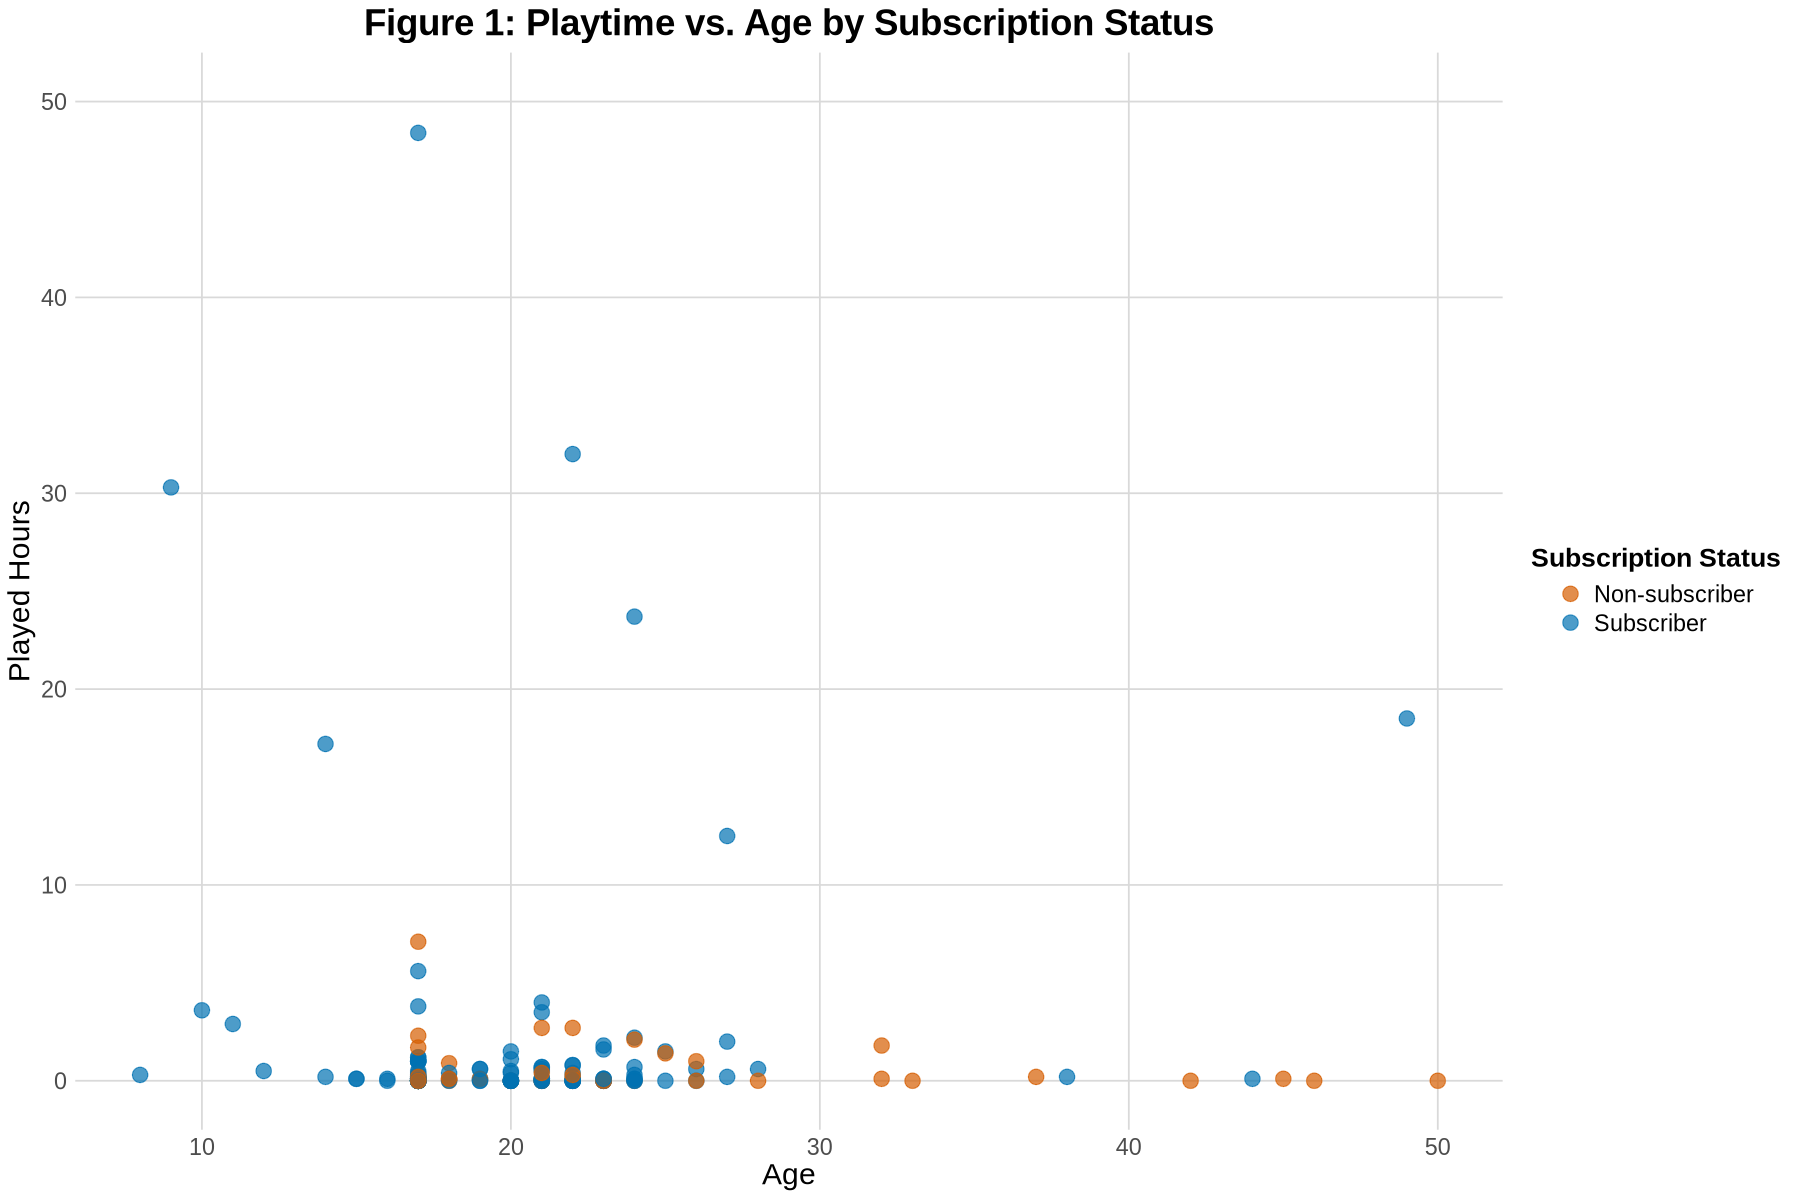

In [10]:
# Set the plot dimensions for clarity
options(repr.plot.width = 15, repr.plot.height = 10)

# Enhanced scatter plot
ggplot(players, aes(x = age, y = played_hours, color = subscriber_status)) +
  geom_point(alpha = 0.7, size = 4) +                                  # Bigger points for better visibility
  labs(
    title = "Figure 1: Playtime vs. Age by Subscription Status",                
    x = "Age",                                                         
    y = "Played Hours",                                               
    color = "Subscription Status"                                     
  ) +
  coord_cartesian(ylim = c(0, 50)) +                                   # Focus on typical playtime
  scale_color_manual(values = c("Non-subscriber" = "#D55E00", "Subscriber" = "#0072B2")) +  # Better color contrast
  theme_minimal() +                                                   # Clean background
  theme(
    plot.title = element_text(hjust = 0.5, face = "bold", size = 22), # Centered, larger title
    axis.text = element_text(size = 14),                              # Axis tick labels
    axis.title = element_text(size = 18),                             # Axis titles
    legend.title = element_text(face = "bold", size = 16, hjust = 0.5), 
    legend.text = element_text(size = 14),
    panel.grid.major = element_line(color = "grey85"),
    panel.grid.minor = element_blank()
  )

## 4. Data Analysis (Establishing classification model/recipe & finding best k) 

In [11]:
# Create a tibble of k values to try (from 1 to 40)
# These represent the different numbers of neighbors we want to evaluate for KNN
k_vals <- tibble(neighbors = seq(from = 1, to = 40, by = 1))

# Define a function to tune KNN for a given random seed
# We run the entire KNN tuning process for one specific seed
tune_knn_for_seed <- function(seed) {
  # Set the random seed for reproducibility
  set.seed(seed)
  
  # Split the data into training and testing sets (75% train, 25% test)
  # Stratified by subscription status to maintain class balance
  players_split <- initial_split(baked_data, prop = 0.75, strata = subscriber_status)
  training_set <- training(players_split)
  testing_set <- testing(players_split)

  # Define a preprocessing recipe (but don't prep yet)
  # We'll scale and center the predictors so KNN isn't biased by their magnitude
  player_recipe_training <- recipe(subscriber_status ~ played_hours + age, data = training_set) |>
    step_scale(all_predictors()) |>
    step_center(all_predictors())
  
  # Define a tunable KNN model specification
  # We set `neighbors = tune()` so that we can try multiple k-values during tuning
  knn_spec <- nearest_neighbor(weight_func = "rectangular", neighbors = tune()) |>
    set_engine("kknn") |>
    set_mode("classification")
  
  # Create 10-fold cross-validation folds
  # Again, stratify by class to keep class balance in each fold
  cv_folds <- vfold_cv(training_set, v = 10, strata = subscriber_status)
  
  # Set up the modeling workflow
  # Add recipe and model to a workflow, then tune across the k values using the CV folds
  tuned <- workflow() |>
    add_recipe(player_recipe_training) |>
    add_model(knn_spec) |>
    tune_grid(
      resamples = cv_folds,  # Use our 10-fold CV
      grid = k_vals          # Try all values of k from 1 to 40
    ) |>
    collect_metrics() |>     # Get accuracy metrics for each k
    filter(.metric == "accuracy") |>  # Only keep accuracy (ignore other metrics)
    mutate(seed = seed)      # Tag results with the seed used
  
  return(tuned)  # Return the accuracy results for all k values for this seed
}

# Step 6: Repeat the tuning process across 10 seeds
# This helps ensure our tuning isn't biased by one random split of the data
seeds <- 6172:6182
all_knn_results <- map_dfr(seeds, tune_knn_for_seed)  # Combine results from all seeds


In [12]:
# Step 1: Compute the average accuracy for each k value across all seeds

mean_accuracies <- all_knn_results |> 
  group_by(neighbors) |>                         # Group results by number of neighbors (k)
  summarise(mean_accuracy = mean(mean),          # Compute the average accuracy for each k
            .groups = "drop")                    # Drop the grouping structure from the output

# View the average accuracies for each k
mean_accuracies

# Step 2: Find the best-performing k values based on average accuracy

best_k <- mean_accuracies |> 
  arrange(desc(mean_accuracy)) |>  # Sort k values in descending order of accuracy
  slice(1:5) |>                    # Select the top 5 highest-performing k values
  pull(neighbors)                 # Extract just the k values (not the accuracy)

# View the best k values
best_k


neighbors,mean_accuracy
<dbl>,<dbl>
1,0.6821488
2,0.6791736
3,0.6186777
⋮,⋮
38,0.5850826
39,0.5902066
40,0.5857438


[1] 1 2 4 3 6

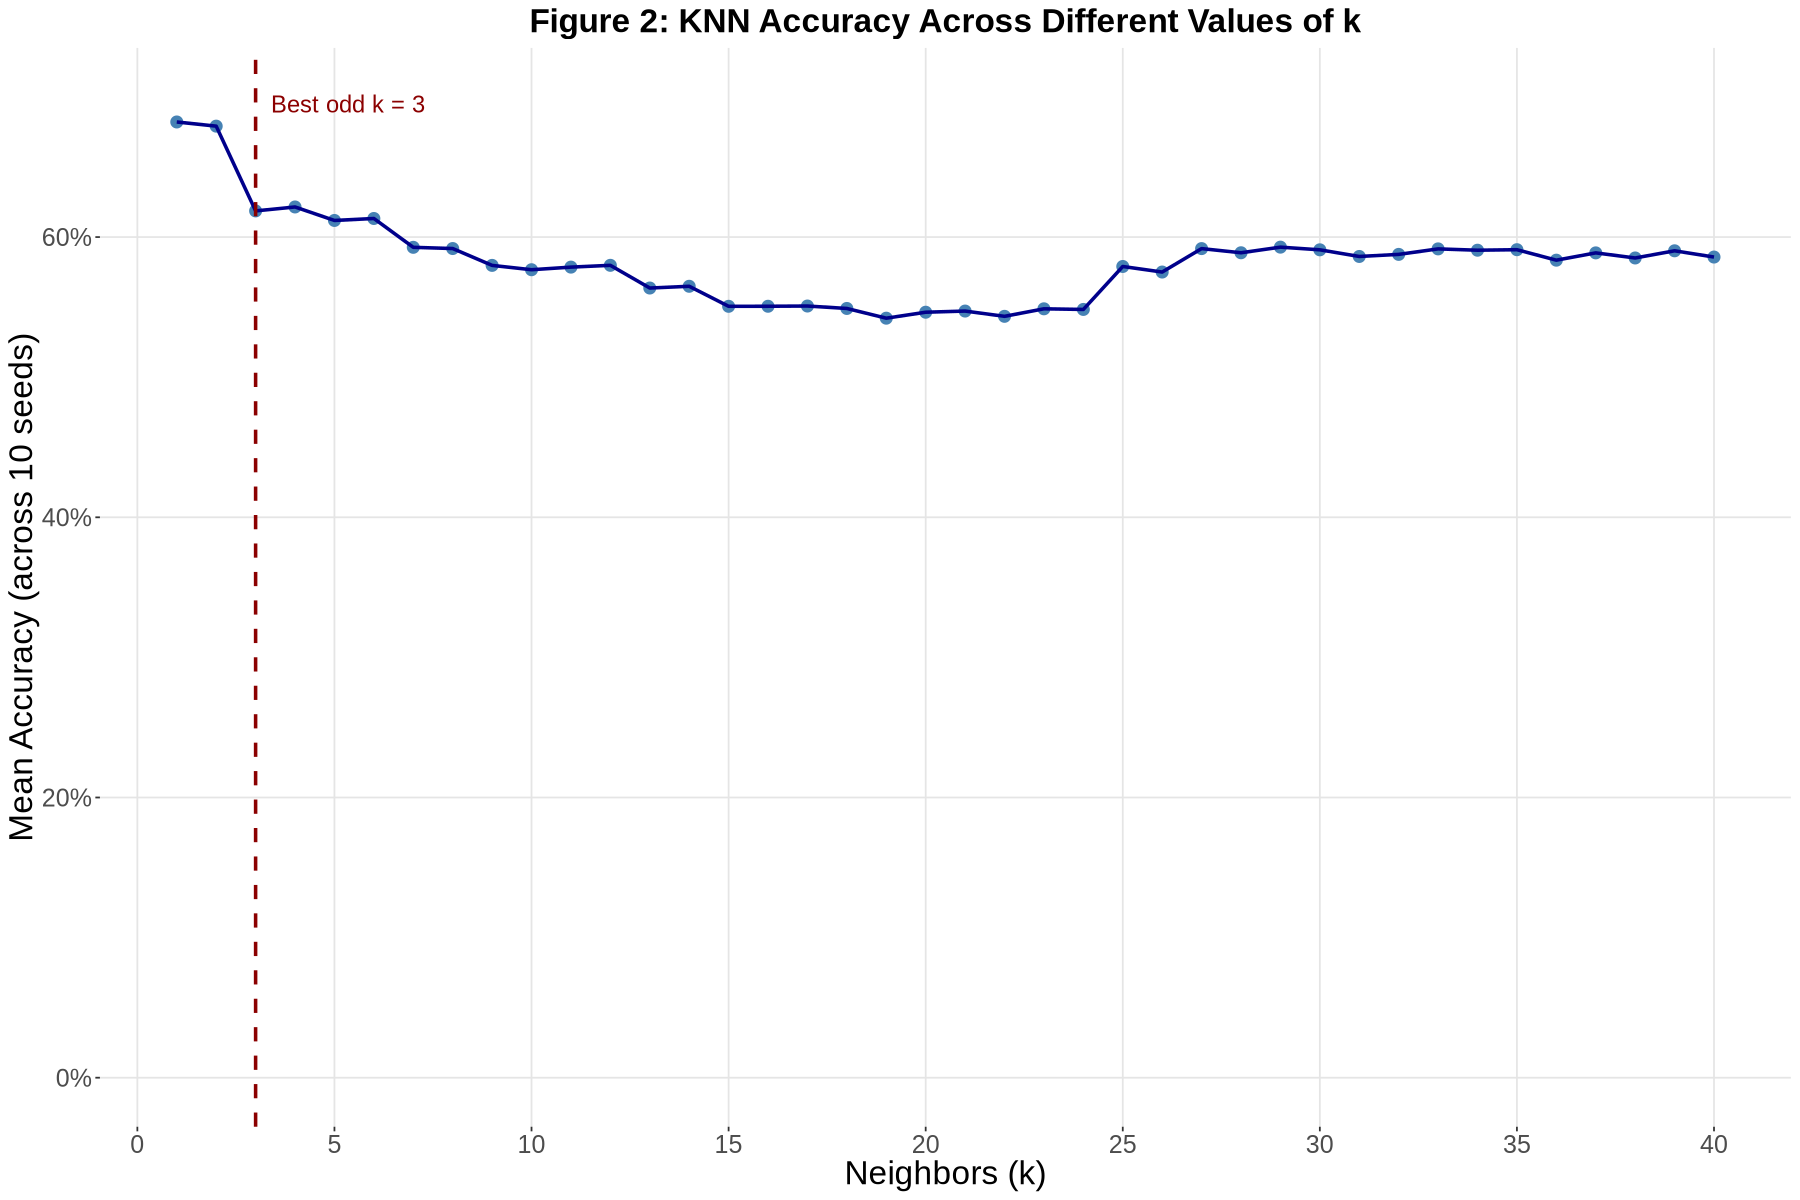

In [13]:
# Plot the average KNN accuracy across different values of k (number of neighbors)
options(repr.plot.width = 15, repr.plot.height = 10)
ggplot(mean_accuracies, aes(x = neighbors, y = mean_accuracy)) +
  geom_point(size = 3, color = "steelblue") +                      
  geom_line(color = "darkblue", linewidth = 1) +                    
  labs(
    title = "Figure 2: KNN Accuracy Across Different Values of k",
    x = "Neighbors (k)",
    y = "Mean Accuracy (across 10 seeds)"
  ) +
  scale_x_continuous(breaks = seq(0, 40, by = 5)) +                 
  scale_y_continuous(limits = c(0, 0.7), labels = scales::percent_format(accuracy = 1)) +
  theme(
    plot.title = element_text(hjust = 0.5, face = "bold", size = 20), 
    axis.text.x = element_text(size = 15),                            
    axis.text.y = element_text(size = 15),
    axis.title.x = element_text(size = 20),                           
    axis.title.y = element_text(size = 20),
    panel.background = element_rect(fill = "white"),                 
    panel.grid.major = element_line(color = "grey90"),               
    panel.grid.minor = element_blank()
  ) + geom_vline(xintercept = 3, linetype = "dashed", color = "darkred", linewidth = 1) +
  annotate("text", x = 3, y = 0.695, label = "Best odd k = 3", color = "darkred", size = 5, hjust = -0.1)


# We will select the *odd-numbered* k that has the highest accuracy because:
# → In binary classification, using an odd k helps avoid ties in majority voting.
# → This ensures the model always makes a decision without randomly breaking ties.
# → If the top-performing k is even, we typically choose the closest odd number with comparable accuracy.

In [14]:
# NOTE:
# We're redefining these objects in the global environment because earlier they were created inside a function.
# In R, anything defined inside a function is local to that function and disappears afterward. By creating them again here, we can use them in later code chunks (e.g., training the final model, plotting, etc.)

# Step 1: Split the preprocessed dataset (baked_data) into training and testing sets
# Use stratified sampling based on `subscriber_status` to preserve class proportions
players_split <- initial_split(baked_data, prop = 0.75, strata = subscriber_status)
training_set <- training(players_split)   # 75% for training
testing_set <- testing(players_split)     # 25% for testing

# Step 2: Define a new recipe on the training set
# We apply the same preprocessing steps (centering and scaling predictors)
player_recipe_training <- recipe(subscriber_status ~ played_hours + age, data = training_set) |>
  step_scale(all_predictors()) |>
  step_center(all_predictors())

# Step 3: Check class balance in the training set
training_set |>
  count(subscriber_status) |>          
  mutate(prop = n / sum(n))            

# Step 4: Check class balance in the testing set
testing_set |>
  count(subscriber_status) |>
  mutate(prop = n / sum(n))           

# These checks ensure that stratified splitting worked correctly, and both sets maintain roughly equal representation of each class.


subscriber_status,n,prop
<fct>,<int>,<dbl>
Non-subscriber,106,0.5
Subscriber,106,0.5


subscriber_status,n,prop
<fct>,<int>,<dbl>
Non-subscriber,36,0.5
Subscriber,36,0.5


In [15]:
# Define the final KNN model specification
knn_spec <- nearest_neighbor(
    weight_func = "rectangular",   # Use uniform (non-weighted) voting among neighbors
    neighbors = 3                  # Use the best odd k value found during tuning
  ) |>
  set_engine("kknn") |>            # Specify the engine to use for KNN (kknn package)
  set_mode("classification")       # Set mode to classification (since we're predicting categories)

# Create a modeling workflow and train (fit) the final model
knn_fit <- workflow() |>
  add_recipe(player_recipe_training) |>   # Add the preprocessing recipe (scaling & centering)
  add_model(knn_spec) |>                  # Add the finalized KNN model spec
  fit(data = training_set)                # Fit the model to the training data

# View the trained model/workflow
knn_fit


══ Workflow [trained] ══════════════════════════════════════════════════════════
Preprocessor: Recipe
Model: nearest_neighbor()

── Preprocessor ────────────────────────────────────────────────────────────────
2 Recipe Steps

• step_scale()
• step_center()

── Model ───────────────────────────────────────────────────────────────────────

Call:
kknn::train.kknn(formula = ..y ~ ., data = data, ks = min_rows(3,     data, 5), kernel = ~"rectangular")

Type of response variable: nominal
Minimal misclassification: 0.3301887
Best kernel: rectangular
Best k: 3

In [16]:
# Predict on the testing set using the final trained KNN model
# The result is a tibble with a `.pred_class` column indicating predicted classes
players_test_predictions <- predict(knn_fit, testing_set) |>
  bind_cols(testing_set)  # Combine predictions with the original test data to evaluate

# Calculate evaluation metrics
# - `metrics()` provides accuracy and Cohen's Kappa (kap)
# - `precision()` tells us how many predicted "Non-subscribers" were correct
# - `recall()` tells us how many actual "Non-subscribers" were correctly predicted
# `event_level = "first"` treats "Non-subscriber" (the first factor level) as the positive class
bind_rows(
  players_test_predictions |> 
    metrics(truth = subscriber_status, estimate = .pred_class),
  
  players_test_predictions |> 
    precision(truth = subscriber_status, estimate = .pred_class, event_level = "first"),
  
  players_test_predictions |> 
    recall(truth = subscriber_status, estimate = .pred_class, event_level = "first")
)

.metric,.estimator,.estimate
<chr>,<chr>,<dbl>
accuracy,binary,0.6388889
kap,binary,0.2777778
precision,binary,0.5892857
recall,binary,0.9166667


In [17]:
# Create a confusion matrix
# This shows how many samples were correctly and incorrectly classified
confusion <- players_test_predictions |>
  conf_mat(truth = subscriber_status, estimate = .pred_class)

# View the confusion matrix
confusion

                Truth
Prediction       Non-subscriber Subscriber
  Non-subscriber             33         23
  Subscriber                  3         13

In [18]:
# Prep the recipe on the training data
# We create a new version (player_recipe_training2) and run `prep()` on it so that we can later use it with `bake()` to preprocess new data
player_recipe_training2 <- recipe(subscriber_status ~ played_hours + age, data = training_set) |> 
  step_scale(all_predictors()) |>      # Standardize predictors: scale to unit variance
  step_center(all_predictors()) |>     # Standardize predictors: center to mean = 0
  prep()                               # Preps the recipe (estimates means/SDs from training data)

# Define a new observation (e.g., a new player)
# This observation is outside your original dataset
new_observation <- tibble(played_hours = 5.0, age = 20)

# Preprocess the new observation using the prepped recipe
# This applies the same centering and scaling as used during training
new_baked <- bake(player_recipe_training2, new_data = new_observation)

# Predict the class label using the trained KNN model
predict(knn_fit, new_data = new_baked)


.pred_class
<fct>
Subscriber


## 5. Results & Analysis Visualization 

In [19]:
# Plot the decision regions and overlay the actual data
wkflw_plot <- ggplot() +
  # Background prediction regions
  geom_point(
    data = prediction_table,
    aes(x = age, y = played_hours, color = Class),
    alpha = 0.04,
    size = 4,
    shape = 15  # square shape for smoother decision shading
  ) +
  # Actual player data points
  geom_point(
    data = players,
    aes(x = age, y = played_hours, color = subscriber_status),
    size = 3,
    alpha = 0.85
  ) +
  # Labels and scale
  labs(
    title = "Figure 3: KNN Decision Regions with Actual Player Data",
    x = "Age",
    y = "Played Hours",
    color = "Subscription Status"
  ) +
  scale_color_manual(values = c(
    "Non-subscriber" = "darkorange",
    "Subscriber" = "steelblue"
  )) +
  coord_cartesian(ylim = c(0, 230)) +
  theme_minimal() +
  theme(
    plot.title = element_text(hjust = 0.5, face = "bold", size = 20),
    axis.title = element_text(size = 16),
    axis.text = element_text(size = 13),
    legend.title = element_text(face = "bold", size = 14),
    legend.text = element_text(size = 12)
  )

# Display the final plot
wkflw_plot


ERROR: Error in eval(expr, envir, enclos): object 'prediction_table' not found


In [ ]:
# Convert confusion matrix to a data frame
confusion_df <- as.data.frame(confusion$table)

# Mark whether each cell is a correct prediction
confusion_df$Correct <- confusion_df$Prediction == confusion_df$Truth

# Plot for correct/incorrect
ggplot(confusion_df, aes(x = Prediction, y = Truth, fill = Correct)) +
  geom_tile(width = 0.95, height = 0.95, color = "white", linewidth = 0.5) +
  geom_text(
    aes(label = Freq),
    size = 6,
    fontface = "bold",
    color = "black"
  ) +
  scale_fill_manual(
    values = c(`TRUE` = "#A8E6A3",   
               `FALSE` = "#F4A6A6"),
    labels = c("Incorrect", "Correct")
  ) +
  labs(
    title = "Figure 4: Confusion Matrix – KNN Test Performance",
    x = "Predicted Class",
    y = "Actual Class",
    fill = "Prediction Match"
  ) +
  scale_x_discrete(position = "top") +
  coord_fixed() +
  theme_minimal() +
  theme(
    plot.title = element_text(hjust = 0.5, face = "bold", size = 18),
    axis.title = element_text(size = 15),
    axis.text = element_text(size = 13),
    legend.position = "bottom",
    legend.title = element_text(face = "bold", size = 14),
    legend.text = element_text(size = 12)
  )




## Discussion

### Summarize What You Found

Based on the analysis of the players dataset, our study revealed notable differences between subscribers and non-subscribers. In particular, subscribers tend to have significantly higher played hours compared to non-subscribers, and they are, on average, slightly younger. The KNN model, built using only played_hours and age, achieved a moderate overall accuracy of around 61%, with a high recall value 94% of indicating that most actual non-subscibers were correctly identified. Tuning experiments further demonstrated that using an odd number for k (e.g., k = 3) helped avoid tie votes, contributing to more stable predictions. Overall, the data suggest that both behavioral (played hours) and demographic (age) factors are important predictors of newsletter subscription.

We didn't pick 1 or 2 for k even though they showed a higher accuracy because smaller k values tend to overfit the data by capturing noise and local fluctuations, additionally, using k = 2 would cause ties to happen. In contrast, using k = 3 provides a more balanced approach—it smooths out the noise and leads to more stable and reliable predictions, even if the accuracy on a particular split appears slightly lower. This choice helps ensure that our model will perform more reliably when applied to unseen data.

We decided to use step_upsample to make both classes equal because without it, we found that the model would pick large k's (around 20-23) that took advantage of the class imbalance (the number of non-subscribers in the dataset was only 52, approximately 36.5% of the dataset). In turn, this made it seem like it had a high accuracy when it was just picking everything as subscribed, because the imbalance allowed the model to achieve seemingly good performance by simply favoring the majority class.

By balancing the classes with step_upsample, the model was forced to learn meaningful patterns from both subscribers and non-subscribers. This resulted in a more realistic and fair evaluation of its predictive performance, ensuring that the accuracy metric truly reflected the model’s ability to differentiate between the two groups. The improved balance led to a valid precision and recall for the minority class, which is critical for understanding the full spectrum of player behavior.

We also decided to find k based on 10 different set seeds because using multiple seeds helps mitigate the impact of randomness in data splitting. Relying on a single seed might lead to a hyperparameter selection that overfits to a particular train-test split, potentially skewing the model's performance. By averaging the accuracy over 10 different seeds, we obtain a more reliable estimate of the model’s performance, ensuring that our choice of k truly reflects the underlying patterns in the data rather than random chance. This approach increases our confidence that the model will generalize well to unseen data. However, while increasing the number of seeds beyond 10 could further stabilize the results, it would also significantly slow down code execution, making the tuning process impractically time-consuming.

### Discuss whether this is what you expected to find? Discuss what impact could such findings have?

Based on our current analysis, the two features we focused on (played_hours and age) demonstrated that subscribers are generally more engaged (with significantly higher played hours) and tend to be younger compared to non-subscribers. This supports our hypothesis that these characteristics are predictive of subscribing to a game-related newsletter. In essence, players who invest more time in the game and are younger appear more likely to be interested in receiving game-related communications. However, while these trends are clear, our model’s overall moderate accuracy (around 61%) and metrics such as Cohen’s Kappa, precision, and recall indicate that these two factors alone explain only part of the variance in subscription behavior.

The performance metrics also shed light on the model's strengths and weaknesses. For example, while our model exhibits a high recall for non-subscribers (when non-subscribers are treated as the positive class), this comes at the expense of precision—meaning that some subscribers are misclassified as non-subscribers. This trade-off suggests that although played_hours and age are valuable predictors, they do not capture the full complexity of why a player might subscribe. Additional features, such as the number of in-game achievements, session frequency, or even social interaction patterns (which is studied through the PLAICRAFT project), could further distinguish the nuances between different player types and improve the model’s predictive power.

Ultimately, these findings emphasize that while higher engagement and a younger demographic are important factors in predicting subscription, the landscape is likely more complex. The goal of understanding which player characteristics and behaviors drive subscription decisions—and how these differ among various player types—opens up several avenues for future research. Incorporating a wider range of variables could not only improve model performance but also provide deeper insight into how different player segments interact with game-related content. Such insight could be invaluable for tailoring marketing strategies and personalizing communications to effectively target each segment of the player base.

For example, suppose our analysis shows that players who subscribe are generally younger and play more than 0 hours. With this insight, a game developer could design a marketing campaign that targets this segment specifically. They might create a newsletter featuring exclusive content—such as sneak peeks at upcoming game features, behind-the-scenes videos, and early access to new levels—that appeals to younger, highly engaged players. Simultaneously, the company could develop a separate strategy for less engaged or older players, such as personalized emails offering gameplay tips or incentives to increase playtime, with the aim of gradually boosting their engagement and interest in subscribing. By tailoring these communications to each player segment based on their unique characteristics and behaviors, the company can more effectively convert players into subscribers and improve overall engagement.


### Discuss what future questions could this lead to?


Our analysis of played_hours and age as predictors prompts us to explore additional dimensions of player behavior. For instance, would incorporating metrics such as session frequency, average session duration, or even the number of in-game achievements further improve our ability to predict newsletter subscription? We could investigate whether players who log in daily or reach specific in-game milestones are more likely to subscribe compared to those with sporadic engagement, thereby providing a more granular understanding of player engagement.

Another specific question is how demographic factors and cultural differences influence subscription behavior. Are the observed patterns consistent across different regions, or do factors like language, socioeconomic status, or local gaming trends alter the relationship between age, played_hours, and subscription? For example, we could compare the predictive power of these variables among players in North America versus those in Europe or Asia, which could lead to tailored marketing strategies for each segment.

Finally, future research could examine the effect of external events and targeted marketing efforts on subscription rates. For instance, does the launch of a new game feature or an in-game event lead to a spike in subscriptions, and how do such interventions interact with baseline player behavior? A longitudinal study comparing subscription rates before and after these events could offer valuable insights into the dynamics of player engagement, ultimately guiding more effective and personalized communication strategies.


## References